**Lý thuyết lấy từ sách Data Mining Concepts and Technique 4th , Digital Image Processing 3rd**

**Công thức tính mean intensity và standard deviation**

*   **Giá trị trung bình (Mean):** Công thức tính là trung bình cộng của tất cả các giá trị quan sát trong tập dữ liệu: $\bar{x} = \frac{1}{N} \sum_{i=1}^{N} x_i$.
*   **Độ lệch chuẩn (Standard deviation - $\sigma$):** Được tính bằng căn bậc hai của phương sai, công thức là $\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x})^2}$,.


**Tại sao lại cần phân tích độ sáng và độ tương phản?**

Trong phân tích dữ liệu, các giá trị này (về bản chất là trung bình và độ lệch chuẩn) giúp trả lời cho hai câu hỏi cốt lõi: **Dữ liệu tập trung ở đâu?** và **Dữ liệu phân tán như thế nào?**.

*   **Độ sáng (Mean intensity):** Mean đại diện cho trung tâm của một tập hợp các quan sát. Trong xử lý ảnh, giá trị trung tâm này chính là cường độ sáng tổng thể của bức ảnh.
*   **Độ tương phản (Standard deviation):** Độ lệch chuẩn đo lường mức độ dàn trải của dữ liệu; một độ lệch chuẩn thấp cho thấy hầu hết các giá trị đều rất gần với trung bình (ít tương phản), trong khi độ lệch chuẩn cao cho thấy dữ liệu trải rộng trên một phạm vi lớn (độ tương phản cao).
*   **Mean rất nhạy cảm với các giá trị cực đoan outliers**
    -  Chỉ cần một số lượng nhỏ các điểm dữ liệu bất thường cũng đủ để làm thay đổi đáng kể kết quả trung bình của toàn bộ tập dữ liệu
    -  Cụ thể:
        - Kéo giá trị trung bình lên: Ví dụ, mức lương trung bình của một công ty có thể bị đẩy lên rất cao chỉ vì một vài quản lý cấp cao được trả lương cực kỳ hậu hĩnh
        - Kéo giá trị trung bình xuống: Tương tự, điểm thi trung bình của một lớp học có thể bị kéo tụt xuống đáng kể chỉ vì một vài bài thi bị điểm rất kém
**Độ sáng và tương phản toàn cục vs. cục bộ**

Dựa trên các nguyên lý phân tích dữ liệu và ngoại lệ (outliers),:
*   **Toàn cục :** Thể hiện bằng cách đánh giá toàn bộ tập dữ liệu (ví dụ: tính mean và standard deviation trên toàn bộ bức ảnh). Nó mang lại cái nhìn bao quát nhưng có thể che lấp các chi tiết cụ thể.
*   **Có thể có cục bộ không:** Phân tích cục bộ là khi bạn chỉ tính toán trên một **khu vực lân cận (neighborhood)** hoặc một bối cảnh (context) cụ thể của dữ liệu,,.
*   **Sự khác nhau:** Tính toàn cục so sánh một điểm với toàn bộ tập dữ liệu, trong khi tính cục bộ so sánh sự phân tán và mật độ của điểm đó với các hàng xóm (neighbor) gần nó nhất,. Trong một hình ảnh có độ tương phản toàn cục thấp, bạn vẫn có thể tìm thấy các vùng (cụm) có độ tương phản cục bộ rất cao hoặc sự bất thường ở khu vực đó nếu bạn phân tích theo khu vực lân cận.

**Cách nhìn và vẽ box plot phân lớp**

*   **Cách nhìn (Đọc Box plot):**
    *   **Hộp (Box):**Hai đầu của hộp nằm ở Q1 (phân vị 25%) và Q3 (phân vị 75%). Chiều dài của hộp chính là Khoảng tứ phân vị (Interquartile Range - IQR), chứa 50% dữ liệu ở giữa.
    *   **Trung vị (Median):** Được đánh dấu bằng một đường kẻ ngang nằm bên trong hộp.
    *   **Râu (Whiskers):** Là hai đường thẳng kéo dài ra bên ngoài hộp đến các giá trị nhỏ nhất và lớn nhất.
    *   **Outliers:** Nếu một giá trị rơi vào vùng lớn hơn $Q3 + 1.5 \times IQR$ hoặc nhỏ hơn $Q1 - 1.5 \times IQR$, chúng thường bị nghi ngờ là ngoại lệ. Khi đó, râu của Box plot sẽ chỉ dừng lại ở giá trị xa nhất nằm trong giới hạn này, và các ngoại lệ sẽ được vẽ dưới dạng các điểm riêng lẻ (dấu chấm),.
*   **Cách vẽ Box plot phân lớp:** Để phân lớp và so sánh các tập dữ liệu với nhau, ta tính toán các giá trị thống kê nêu trên cho từng nhóm (lớp) riêng biệt và vẽ các Box plot của chúng **đặt cạnh nhau** trên cùng một biểu đồ. Việc này cho phép ta so sánh trực quan mức độ tập trung, độ phân tán và các giá trị ngoại lệ của nhiều tập dữ liệu cùng một lúc (ví dụ: Box plot so sánh giá bán ở 4 chi nhánh khác nhau),.
![image.png](https://miro.medium.com/max/9000/1*2c21SkzJMf3frPXPAR_gZA.png)

In [1]:
import sys, os, warnings
from IPython.display import display

# 1. Tắt toàn bộ các cảnh báo lặt vặt (bao gồm cả cảnh báo Palette của Seaborn)
warnings.filterwarnings("ignore")
os.environ["OPENCV_LOG_LEVEL"] = "SILENT"

# 2. Bật chế độ hiển thị Inline và tự động nạp lại module
%matplotlib inline
%load_ext autoreload
%autoreload 2

# 3. Khai báo đường dẫn src để import module an toàn
if os.path.abspath(os.path.join('..', 'src')) not in sys.path:
    sys.path.append(os.path.abspath(os.path.join('..', 'src')))

from image.dataset import ImageDataset
from config.settings import PATH_FOLDER_IMAGE_RAW

# 4. Khởi tạo Dataset dùng Path chuẩn từ settings.py
print(f"[INFO] Khởi tạo Dataset từ: {PATH_FOLDER_IMAGE_RAW} ...")
dataset = ImageDataset(path=PATH_FOLDER_IMAGE_RAW)

# In thông tin metadata
dataset.info()

[INFO] Khởi tạo Dataset từ: /home/giahan/data-mining-preprocessing-project/data/image ...
Metadata of Dataset
	Folder Path: /home/giahan/data-mining-preprocessing-project/data/image
	Total Images: 0
	Image Size:(128, 128)
	Dataset Shape:(0, 0, 0, 0) (N,H,W,C)
	Name of file of 5 first sample



[INFO] Bắt đầu phân tích Độ sáng (Brightness) & Độ tương phản (Contrast)...


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


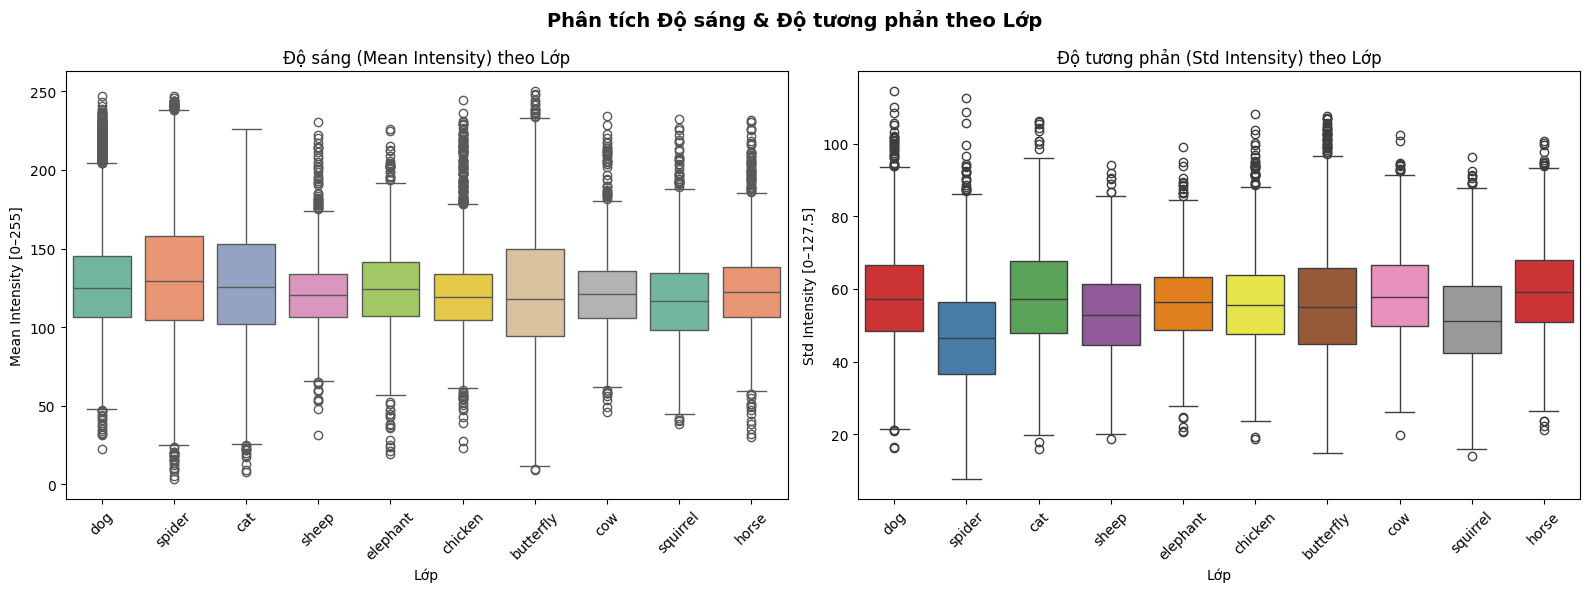


## Nhận xét: Phân tích Độ sáng & Độ tương phản theo Lớp

### 1. Độ sáng (Brightness — Mean Intensity)

**Median theo lớp:**
- Class **spider** có median cao nhất `(129.69)` → ảnh sáng nhất trung bình.
- Class **squirrel** có median thấp nhất `(116.61)` → ảnh tối nhất trung bình.

**Phương sai (Variance) theo lớp:**
- Class **butterfly** có variance lớn nhất `(2039.64)` → độ sáng phân tán rộng, ảnh trong lớp không đồng đều.
- Class **sheep** có variance nhỏ nhất `(588.11)` → ảnh trong lớp khá đồng đều về độ sáng.

**IQR (boxplot) theo lớp:**
- Các class có IQR lớn: **butterfly, cat, dog, spider, squirrel** → hộp boxplot rộng, phân bố độ sáng biến động đáng kể trong lớp.
- Các class có IQR nhỏ: **chicken, cow, elephant, horse, sheep** → hộp boxplot hẹp, ảnh trong lớp có độ sáng tập trung.

**Outliers:**
- Các class có nhiều outlier về độ sáng: **chicken, dog, horse, sheep, spider** → tồn tại ảnh có độ sáng bất thường, có thể gây nhiễu khi huấn luyện.

---

### 2. Độ tương phản (Contrast — Std Intensity)

**Phương sai (Variance) theo lớp:**
- Class **butterfly** có variance lớn nhất `(263.73)` → độ tương phản giữa các ảnh trong lớp dao động nhiều.
- Class **elephant** có variance nhỏ nhất `(137.12)` → độ tương phản khá đồng nhất trong lớp.

**Outliers:**
- Các class có nhiều outlier về độ tương phản: **butterfly, chicken, dog, elephant, spider** → một số ảnh có độ tương phản rất khác biệt so với phần còn lại của lớp.


Step    : Analysis Contrast & Brightness
Dataset : /home/giahan/data-mining-preprocessing-project/data/image
Status  : Success

── Global (toàn bộ data) ──
  brightness    mean=125.78  var=1228.62
  contrast      mean=54.87  var=199.62

── Theo từng class ──
            brightness_mean  brightness_var  brightness_median  brightness_IQR  brightness_n_outliers  contrast_mean  contrast_var  contrast_median  contrast_IQR  contrast_n_outliers
class_name                                                                                                                                                                            
butterfly            125.13         2039.64             117.76           55.71                     19          56.21        263.73            55.00         20.88                   35
cat                  127.73         1621.26             125.62           51.08                     13          57.93        211.25            57.12         19.58                   11
chicken  

In [2]:
from image.analysis_constrast_n_brightness import ContrastAndBrightness
import visualization.relationship as rel
rel.plt.show = lambda: display(rel.plt.gcf())

print("\n[INFO] Bắt đầu phân tích Độ sáng (Brightness) & Độ tương phản (Contrast)...")

# Khởi tạo và chạy Service của Duy
step = ContrastAndBrightness()
step._dataset = dataset
step.run()
step.log()

# Dọn dẹp bộ nhớ RAM sau khi vẽ xong
rel.plt.close('all')